In [1]:
import scanpy as sc
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

In [3]:
img_name = 'W14_pattern2_Sox17_Brachyury_no geltrex'
# img_name = 'W8_pattern1_Sox17_Brachyury'
channel_names = ['Sox17', 'BMP4', 'T', 'Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(82676, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.457594,2690.757396,507.0,97.012193,94.654844,0.760332,0.906977,0.603571,33.380046,21.681514,...,0.711102,1.539562,269.485207,130.072978,158.915187,1567.958580,True,False,False,True
2,4.018692,25.261682,107.0,42.727922,43.190127,0.927025,0.930435,0.849206,19.399281,7.274737,...,0.720816,2.666664,309.859813,120.560748,147.570093,1134.084112,True,False,False,True
3,6.393617,49.037234,188.0,52.384776,52.345399,0.748620,0.979167,0.746032,19.629501,13.014340,...,0.862205,1.508298,295.898936,120.574468,159.670213,1353.069149,True,False,False,True


In [4]:
# img = tiff.imread(f'../data/stitched/{img_name}.tif')

# viewer = napari.Viewer()
# _ = viewer.add_image(
#     img,
#     channel_axis=0, 
#     name=channel_names, 
#     colormap=['magenta', 'red', 'green', 'blue'],
#     blending='additive'
# )


In [5]:
if_cols = [c + '_mean' for c in channel_names if c != 'Hoechst']
fig_dir = f'../results/figures/{img_name}/analysis'
os.makedirs(fig_dir, exist_ok=True)

## Preprocessing

`BMP4+`/`T+` (bimodal-valley thresholds that may not be well calibrated) are used in
exactly one place below -- `dist_to_BMP4_source`, since distance-to-nearest-sender
inherently needs a discrete set of points to measure distance to. Everywhere else,
the continuous `BMP4_mean`/`T_mean` values are used directly.

Two different ways of asking "how much BMP4 is nearby" are computed for every
radius in `RADII` (edit that list to add/remove radii -- every plot below sweeps
across it), each computed ONCE here rather than inline in a plot cell, so
re-running/tweaking a downstream plot never re-triggers the underlying computation:

- **Pixel-based** (`BMP4_dose_r{radius}` / raw): sum of every raw pixel (not masked
  to `BMP4+`) within the radius (`tools.features.radius_total_signal`).
- **Cell-based neighborhood** (`BMP4_mean_neighborhood_total_r{radius}` / raw,
  `log_BMP4_mean_neighborhood_total_r{radius}` / log1p): sum of neighboring CELLS'
  own `BMP4_mean` within the radius (a sum of per-cell means, not pixels), plus a
  log1p'd version for cases where the raw sum's right skew needs taming.
- **`BMP4_sender_count_neighborhood_r{radius}`**: count of `BMP4+` neighbors within
  the radius -- local sender density, distinct from "how bright is BMP4 nearby."

`T_mean` gets its own background-subtract + log1p (`T_mean_scaled`) -- a real IF
channel with a genuine camera-offset/autofluorescence floor to remove first. No
`StandardScaler`/z-scoring anywhere -- values stay in log1p(real units), not
abstract SD units.

In [6]:
RADII = [30, 50, 100, 200, 300]  # px -- edit this list; every radius-dependent plot below sweeps across it

In [7]:
from scipy.spatial import KDTree

source_centroids = cell_df.loc[cell_df['BMP4+'], ['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
all_centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)

source_tree = KDTree(source_centroids)
dist_to_source, nearest_idx = source_tree.query(all_centroids, k=1)
cell_df['dist_to_BMP4_source'] = dist_to_source

print(f"{cell_df['BMP4+'].sum()} BMP4+ sender cells")

4361 BMP4+ sender cells


In [8]:
from tools.features import radius_total_signal
from models.gnn import estimate_background

tif_path = (glob(f'../data/stitched/{img_name}.tif') or glob(f'../data/stitched/{img_name}'))[0]
img = tiff.imread(tif_path)

bmp4_channel_idx = channel_names.index('BMP4')
bmp4_raw = img[bmp4_channel_idx].astype(np.float32)[np.newaxis]  # (1, H, W), untransformed
bmp4_background = estimate_background(cell_df['BMP4_mean'].to_numpy())
bmp4_log_transformed = np.log1p(np.clip(bmp4_raw - bmp4_background, a_min=0.0, a_max=None))

raw_dose_cols = {}
log_dose_cols = {}
for r in RADII:
    raw_dose_df = radius_total_signal(bmp4_raw, cell_df, radius=r, channel_names=['BMP4'])
    raw_col = f'BMP4_dose_r{r}'
    cell_df[raw_col] = raw_dose_df['BMP4_total'].clip(lower=0)
    raw_dose_cols[r] = raw_col

    log_dose_df = radius_total_signal(bmp4_log_transformed, cell_df, radius=r, channel_names=['BMP4'])
    log_col = f'log_BMP4_dose_r{r}'
    cell_df[log_col] = log_dose_df['BMP4_total'].clip(lower=0)
    log_dose_cols[r] = log_col

cell_df[list(raw_dose_cols.values()) + list(log_dose_cols.values())].describe()

,BMP4_dose_r30,BMP4_dose_r50,BMP4_dose_r100,BMP4_dose_r200,BMP4_dose_r300,log_BMP4_dose_r30,log_BMP4_dose_r50,log_BMP4_dose_r100,log_BMP4_dose_r200,log_BMP4_dose_r300
count,8.267600e+04,8.267600e+04,8.267600e+04,82676.0,82676.0,82676.000000,82676.000000,82676.000000,82676.000000,8.267600e+04
mean,4.766951e+05,1.318294e+06,5.262500e+06,21190856.0,47836592.0,3201.940918,8824.741211,35018.179688,140292.531250,3.156819e+05
std,4.457056e+05,1.093143e+06,3.789971e+06,13437751.0,27913954.0,2973.243164,7474.510742,26548.296875,95053.750000,1.975512e+05
min,1.621608e+05,3.655902e+05,1.222375e+06,5085644.0,10262920.0,88.109970,588.919312,4110.208008,28966.767578,6.948608e+04
25%,3.433921e+05,9.596360e+05,3.906113e+06,16619838.0,38205711.0,1571.477905,4802.123047,22196.753418,97285.810547,2.241667e+05
50%,3.500309e+05,9.813249e+05,4.253280e+06,17986387.0,40867258.0,2295.691895,6783.539551,29117.475586,118773.816406,2.663355e+05
75%,3.695332e+05,1.150792e+06,5.007012e+06,19746048.0,44060680.0,3458.469666,9909.934570,37583.133789,143721.937500,3.164826e+05
max,8.246252e+06,1.712482e+07,4.333752e+07,129503600.0,269421952.0,21708.488281,56320.531250,197248.609375,735825.687500,1.605792e+06


In [9]:
from sklearn.neighbors import NearestNeighbors

bmp4_mean_values = cell_df['BMP4_mean'].to_numpy()
is_sender = cell_df['BMP4+'].to_numpy()

nbhd_bmp4_cols = {}
nbhd_bmp4_scaled_cols = {}
nbhd_sender_cols = {}
for r in RADII:
    nn = NearestNeighbors(radius=r).fit(all_centroids)
    neighbor_idxs = nn.radius_neighbors(all_centroids, return_distance=False)
    bmp4_total = np.empty(len(cell_df), dtype=np.float64)
    sender_count = np.empty(len(cell_df), dtype=np.int64)
    for i, idx in enumerate(neighbor_idxs):
        others = idx[idx != i]  # radius_neighbors includes the query cell itself
        bmp4_total[i] = bmp4_mean_values[others].sum()
        sender_count[i] = is_sender[others].sum()

    bmp4_col = f'BMP4_mean_neighborhood_total_r{r}'
    bmp4_scaled_col = f'log_BMP4_mean_neighborhood_total_r{r}'
    sender_col = f'BMP4_sender_count_neighborhood_r{r}'
    cell_df[bmp4_col] = bmp4_total
    cell_df[bmp4_scaled_col] = np.log1p(bmp4_total)
    cell_df[sender_col] = sender_count
    nbhd_bmp4_cols[r] = bmp4_col
    nbhd_bmp4_scaled_cols[r] = bmp4_scaled_col
    nbhd_sender_cols[r] = sender_col

cell_df[list(nbhd_bmp4_cols.values()) + list(nbhd_sender_cols.values())].describe()

,BMP4_mean_neighborhood_total_r30,BMP4_mean_neighborhood_total_r50,BMP4_mean_neighborhood_total_r100,BMP4_mean_neighborhood_total_r200,BMP4_mean_neighborhood_total_r300,BMP4_sender_count_neighborhood_r30,BMP4_sender_count_neighborhood_r50,BMP4_sender_count_neighborhood_r100,BMP4_sender_count_neighborhood_r200,BMP4_sender_count_neighborhood_r300
count,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000,82676.000000
mean,862.195719,2619.549427,10521.690423,40618.794399,89445.156897,0.155898,0.507777,2.205622,9.581027,22.508648
std,851.757845,2105.849354,7202.041205,25491.976518,53644.692649,0.543256,1.382258,4.880479,17.354588,35.815495
min,0.000000,0.000000,965.394525,7083.449215,17863.132327,0.000000,0.000000,0.000000,0.000000,0.000000
25%,490.763026,1707.909840,7474.065410,30017.432867,66571.476972,0.000000,0.000000,0.000000,3.000000,8.000000
50%,744.464360,2318.502177,9224.389231,34794.620430,75912.249333,0.000000,0.000000,1.000000,5.000000,12.000000
75%,986.991393,2880.705721,11100.746169,40684.505688,87318.735012,0.000000,0.000000,2.000000,8.000000,18.000000
max,18786.765001,39303.085119,89268.404789,238404.381503,494291.977374,8.000000,19.000000,45.000000,131.000000,274.000000


In [10]:
cell_df['T_mean_scaled'] = np.log1p(np.clip(
    cell_df['T_mean'].to_numpy() - estimate_background(cell_df['T_mean'].to_numpy()), a_min=0.0, a_max=None
))
cell_df[['T_mean_scaled', 'dist_to_BMP4_source']].describe()

,T_mean_scaled,dist_to_BMP4_source
count,82676.000000,82676.000000
mean,1.149926,99.088153
std,1.429037,60.528917
min,0.000000,0.000000
25%,0.000000,53.278645
50%,0.169368,92.435810
75%,2.139600,137.898140
max,9.576558,357.864379


## Distance to nearest BMP4+ sender

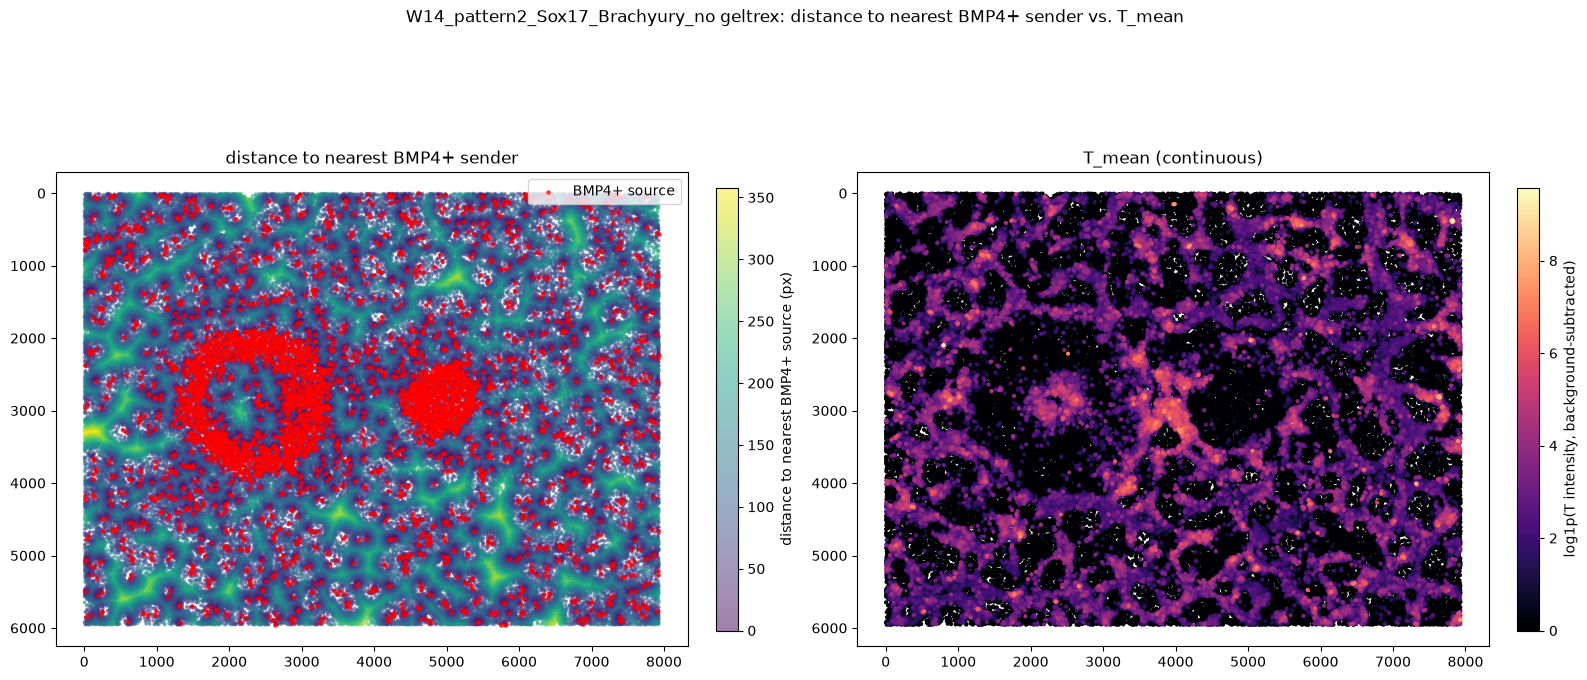

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sc0 = axes[0].scatter(cell_df['centroid_x'], cell_df['centroid_y'], c=cell_df['dist_to_BMP4_source'],
                       cmap='viridis', s=3, alpha=0.5)
axes[0].scatter(cell_df.loc[cell_df['BMP4+'], 'centroid_x'], cell_df.loc[cell_df['BMP4+'], 'centroid_y'],
                c='red', s=6, label='BMP4+ source', alpha=0.6)
axes[0].set_aspect('equal', adjustable='box')
axes[0].invert_yaxis()
axes[0].legend(loc='upper right')
fig.colorbar(sc0, ax=axes[0], label='distance to nearest BMP4+ source (px)', fraction=0.046, pad=0.04, shrink=0.6)
axes[0].set_title('distance to nearest BMP4+ sender')

order = cell_df['T_mean_scaled'].to_numpy().argsort()
sc1 = axes[1].scatter(cell_df['centroid_x'].to_numpy()[order], cell_df['centroid_y'].to_numpy()[order],
                       c=cell_df['T_mean_scaled'].to_numpy()[order], cmap='magma', s=4)
axes[1].set_aspect('equal', adjustable='box')
axes[1].invert_yaxis()
fig.colorbar(sc1, ax=axes[1], label='log1p(T intensity, background-subtracted)', fraction=0.046, pad=0.04, shrink=0.6)
axes[1].set_title('T_mean (continuous)')

fig.suptitle(f'{img_name}: distance to nearest BMP4+ sender vs. T_mean')
fig.tight_layout()
plt.savefig(f'{fig_dir}/dist_to_source_map.png', dpi=300)
plt.show()

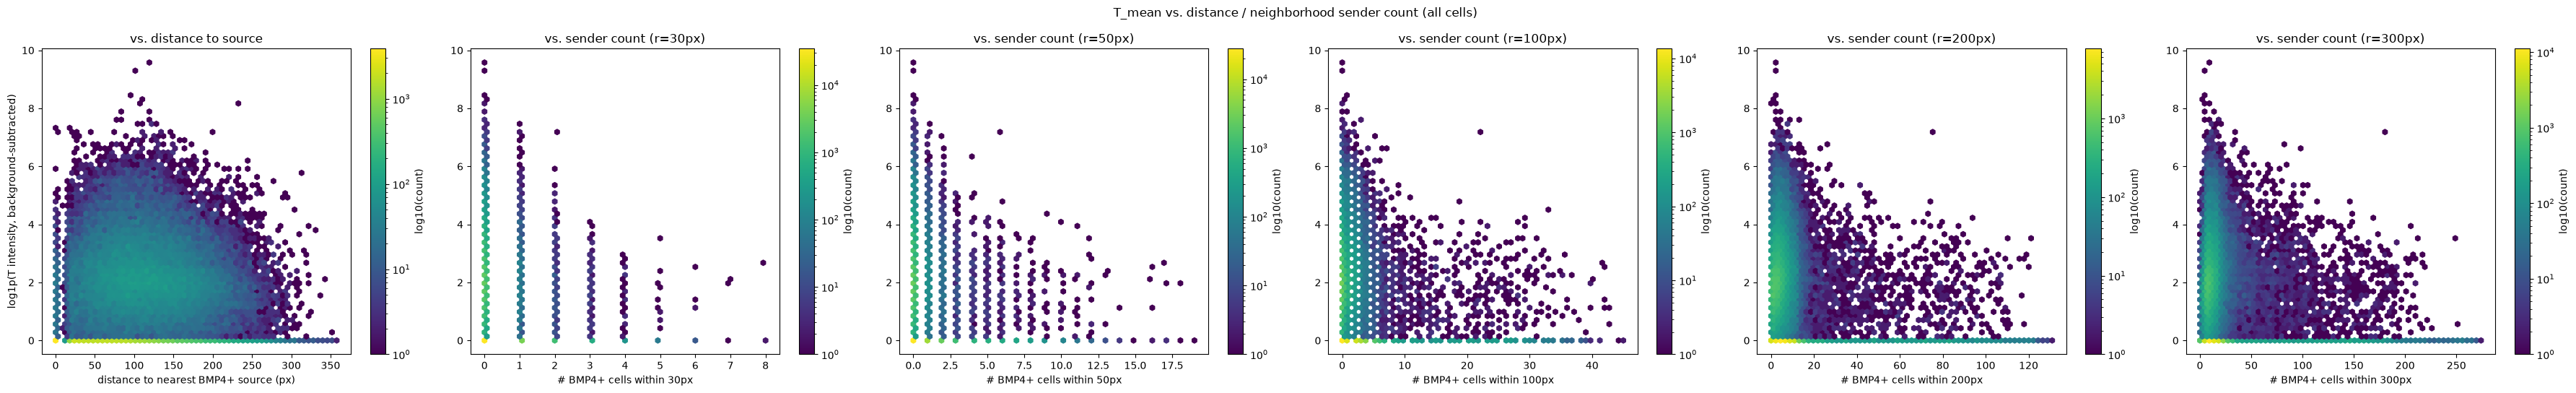

In [12]:
# Left panel: T_mean vs. distance to nearest sender. Remaining panels: T_mean vs.
# number of BMP4+ cells within each radius in RADII -- same continuous relationship,
# density-colored hexbins since most cells sit at background-level T.
fig, axes = plt.subplots(1, 1 + len(RADII), figsize=(6 * (1 + len(RADII)), 5.5))

hb0 = axes[0].hexbin(cell_df['dist_to_BMP4_source'], cell_df['T_mean_scaled'], gridsize=60, bins='log',
                      cmap='viridis', mincnt=1)
axes[0].set_xlabel('distance to nearest BMP4+ source (px)')
axes[0].set_ylabel('log1p(T intensity, background-subtracted)')
axes[0].set_title('vs. distance to source')
fig.colorbar(hb0, ax=axes[0], label='log10(count)')

for ax, r in zip(axes[1:], RADII):
    hb = ax.hexbin(cell_df[nbhd_sender_cols[r]], cell_df['T_mean_scaled'], gridsize=60, bins='log',
                    cmap='viridis', mincnt=1)
    ax.set_xlabel(f'# BMP4+ cells within {r}px')
    ax.set_title(f'vs. sender count (r={r}px)')
    fig.colorbar(hb, ax=ax, label='log10(count)')

fig.suptitle('T_mean vs. distance / neighborhood sender count (all cells)')
fig.tight_layout()
plt.savefig(f'{fig_dir}/dist_to_source_comparison.png', dpi=300)
plt.show()

### Dose dependence

If BMP4 acts as a diffusible morphogen, nearest-source distance is a proxy for local
ligand dose -- a graded response should show `T_mean` falling off with distance.

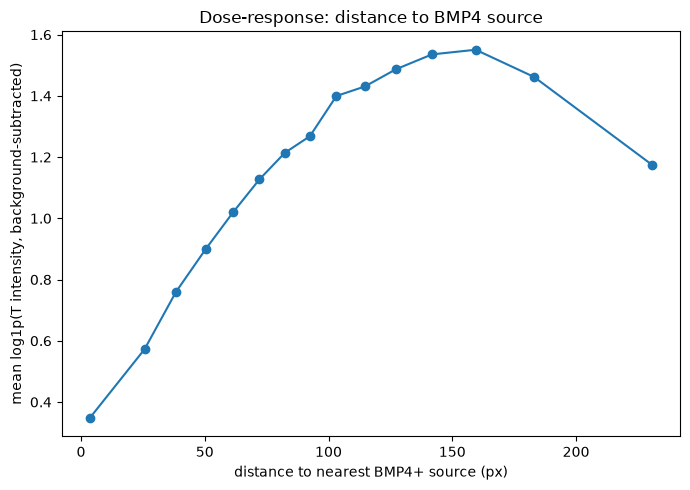

,bin_center,T_mean_avg,n
dist_bin,,,
"(-0.001, 19.24]",3.520366,0.347541,5512
"(19.24, 32.064]",25.675136,0.572449,5512
"(32.064, 44.483]",38.352949,0.759496,5512
"(44.483, 56.071]",50.389645,0.899680,5511
"(56.071, 66.721]",61.447351,1.019812,5512
"(66.721, 77.3]",72.074318,1.127163,5512
"(77.3, 87.407]",82.326657,1.213886,5511
"(87.407, 97.686]",92.478431,1.268338,5512
"(97.686, 108.809]",103.189648,1.399682,5512


In [13]:
N_BINS = 15
cell_df['dist_bin'] = pd.qcut(cell_df['dist_to_BMP4_source'], q=N_BINS, duplicates='drop')

binned_dist = cell_df.groupby('dist_bin', observed=True).agg(
    bin_center=('dist_to_BMP4_source', 'mean'),
    T_mean_avg=('T_mean_scaled', 'mean'),
    n=('T_mean_scaled', 'size'),
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(binned_dist['bin_center'], binned_dist['T_mean_avg'], marker='o')
ax.set_xlabel('distance to nearest BMP4+ source (px)')
ax.set_ylabel('mean log1p(T intensity, background-subtracted)')
ax.set_title('Dose-response: distance to BMP4 source')
fig.tight_layout()
plt.savefig(f'{fig_dir}/dose_response_binned.png', dpi=300)
plt.show()

display(binned_dist)

In [14]:
from scipy.stats import spearmanr, pearsonr

r_s, p_s = spearmanr(cell_df['dist_to_BMP4_source'], cell_df['T_mean'])
r_p, p_p = pearsonr(cell_df['dist_to_BMP4_source'], cell_df['T_mean'])
print('T_mean correlation with distance to BMP4 source')
print(f'Spearman r = {r_s:.3f} (p={p_s:.2e})')
print(f'Pearson  r = {r_p:.3f} (p={p_p:.2e})')

T_mean correlation with distance to BMP4 source
Spearman r = 0.309 (p=0.00e+00)
Pearson  r = 0.035 (p=2.87e-24)


## T vs. BMP4: unscaled and scaled

One reusable grid (scatter / quantile-binned mean / hexbin density, one column per
radius in `RADII`) covers both cases below -- just swap which x/y columns it's given:

- **Unscaled**: raw `T_mean` vs. the raw pixel-based dose (`BMP4_dose_r{radius}`).
- **Scaled**: `T_mean_scaled` vs. the log1p'd cell-neighborhood BMP4 total
  (`log_BMP4_mean_neighborhood_total_r{radius}`) -- a genuinely different "how much
  BMP4 is nearby" operationalization (cell-based, not pixel-based) from the unscaled
  version above, in addition to being on a different scale.

In [15]:
def plot_dose_response_grid(x_cols, y_col, x_label, title, save_name, n_bins=15):
    """3-row grid (scatter / quantile-binned mean / hexbin density) of y_col vs.
    x_cols[r], one column per radius in RADII."""
    fig, axs = plt.subplots(3, len(RADII), figsize=(6 * len(RADII), 12), sharex='col')

    for r, ax_top, ax_mid, ax_bottom in zip(RADII, axs[0], axs[1], axs[2]):
        col = x_cols[r]
        rho, _ = spearmanr(cell_df[col], cell_df[y_col])
        r_p, _ = pearsonr(cell_df[col], cell_df[y_col])

        sns.scatterplot(data=cell_df, y=y_col, x=col, ax=ax_top)
        ax_top.set_title(f'r={r}px\nspearman={rho:.3f}, pearson={r_p:.3f}')

        bins = pd.qcut(cell_df[col], q=n_bins, duplicates='drop')
        binned = cell_df.groupby(bins, observed=True).agg(bin_center=(col, 'mean'), y_avg=(y_col, 'mean'))
        ax_mid.plot(binned['bin_center'], binned['y_avg'], marker='o', color='C4')
        ax_mid.set_xlabel(x_label.format(r=r))
        ax_mid.set_ylabel(f'mean {y_col}')

        ax_bottom.hexbin(cell_df[col], cell_df[y_col], gridsize=50, bins='log', cmap='viridis', mincnt=1)
        # ax_bottom.set_ylim(0, cell_df[y_col].quantile(0.99))
        ax_bottom.set_xlabel(x_label.format(r=r))
        ax_bottom.set_ylabel(y_col)
        ax_bottom.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(f'{fig_dir}/{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

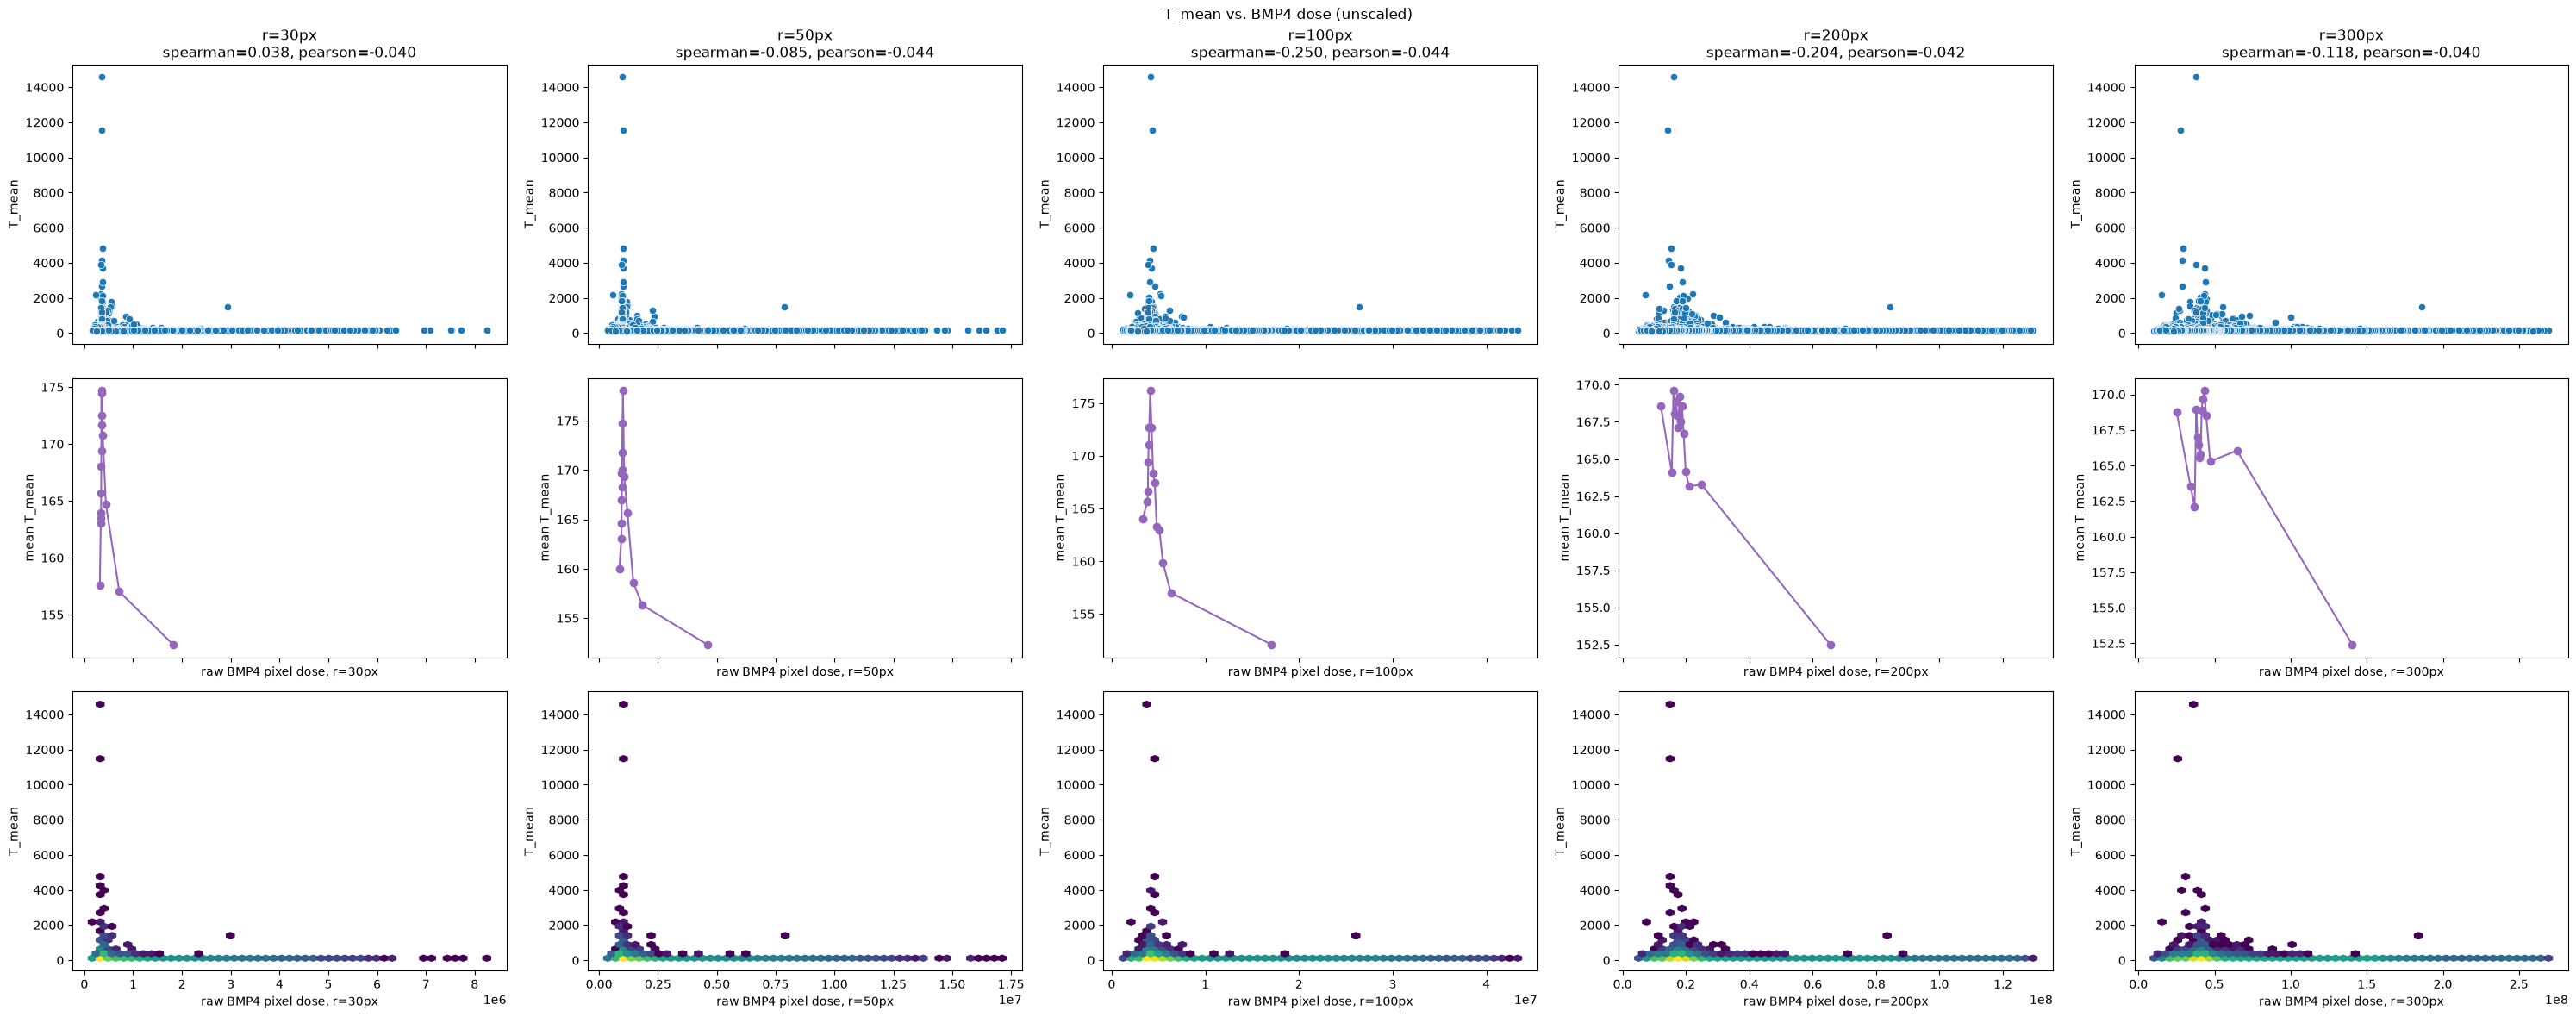

In [16]:
plot_dose_response_grid(
    raw_dose_cols, 'T_mean', 'raw BMP4 pixel dose, r={r}px',
    'T_mean vs. BMP4 dose (unscaled)', 'T_corr_BMP4_unscaled',
)

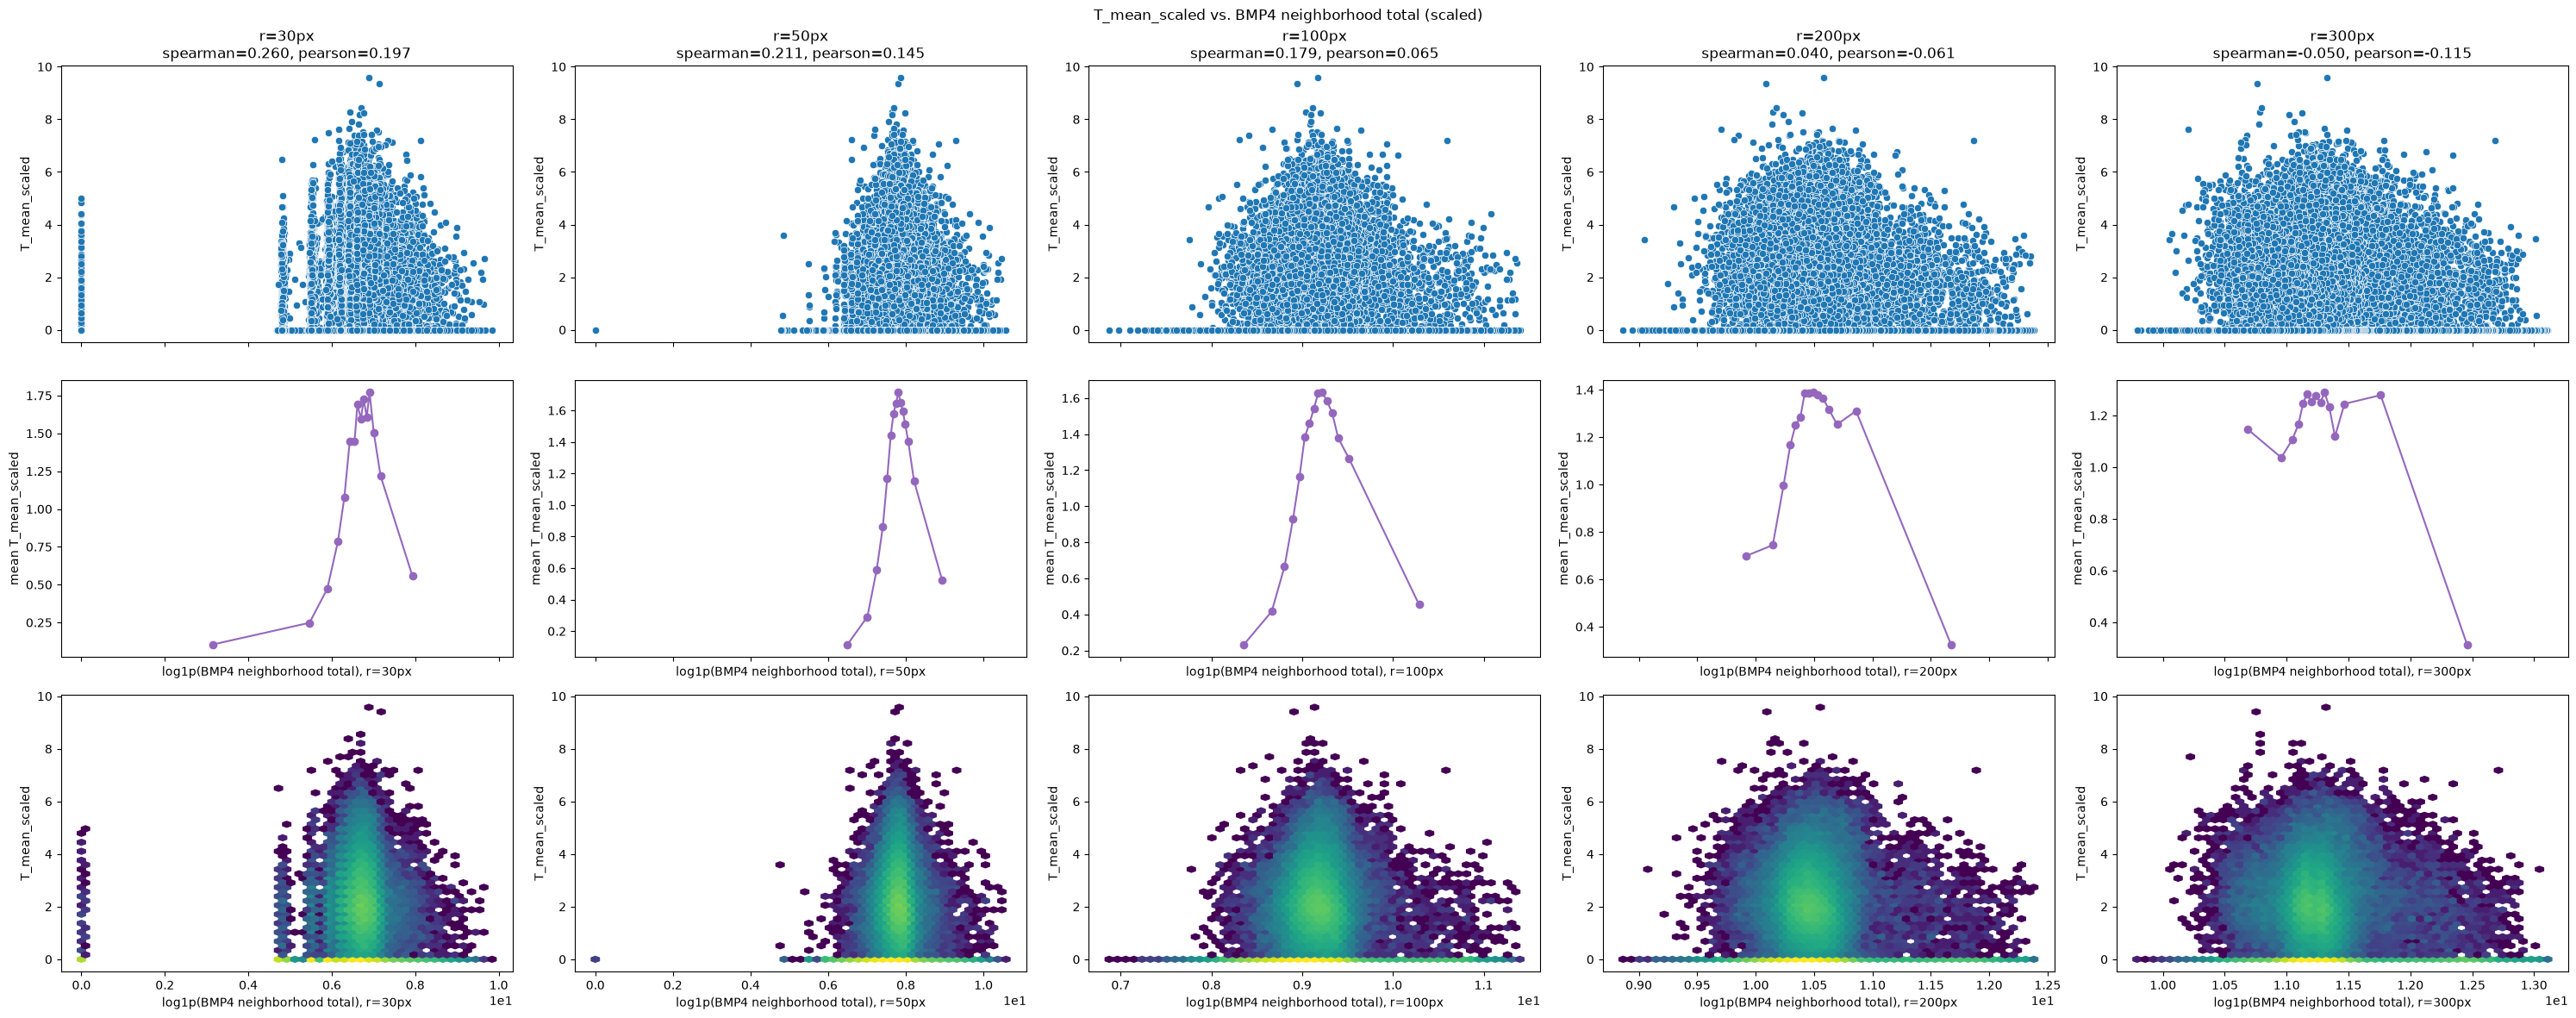

In [17]:
plot_dose_response_grid(
    nbhd_bmp4_scaled_cols, 'T_mean_scaled', 'log1p(BMP4 neighborhood total), r={r}px',
    'T_mean_scaled vs. BMP4 neighborhood total (scaled)', 'T_corr_BMP4_neighborhood_scaled',
)

### Sender count and joint distance x dose

`BMP4_sender_count_neighborhood_r{radius}` (count of `BMP4+` neighbors) is a
genuinely different question from "how bright is BMP4 nearby" above -- a
neighborhood can have a few very bright non-thresholded cells and no senders, or
many senders that are only modestly bright.

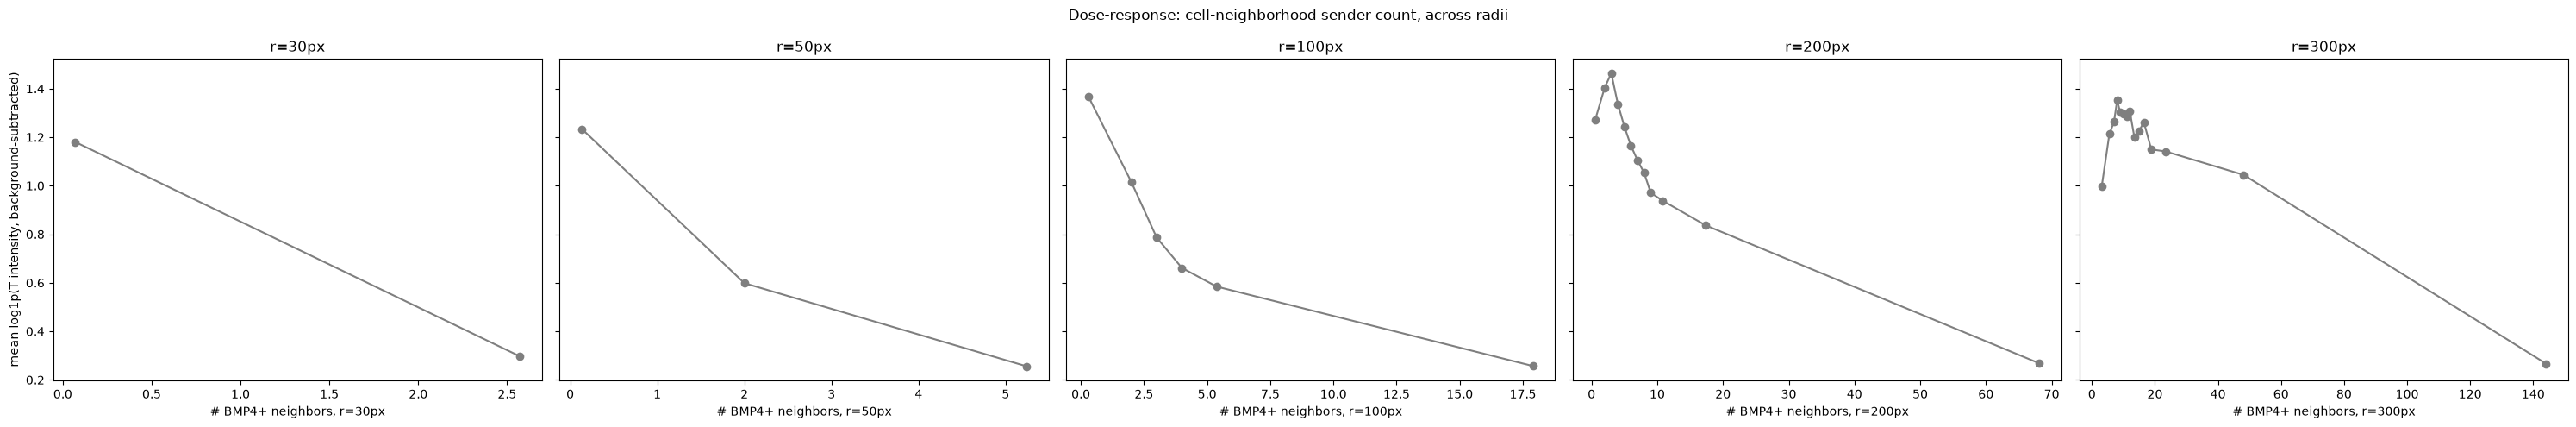

In [18]:
N_BINS = 15
fig, axes = plt.subplots(1, len(RADII), figsize=(6 * len(RADII), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, r in zip(axes, RADII):
    col = nbhd_sender_cols[r]
    bins = pd.qcut(cell_df[col], q=N_BINS, duplicates='drop')
    binned = cell_df.groupby(bins, observed=True).agg(
        bin_center=(col, 'mean'), T_mean_avg=('T_mean_scaled', 'mean'),
    )
    ax.plot(binned['bin_center'], binned['T_mean_avg'], marker='o', color='C7')
    ax.set_xlabel(f'# BMP4+ neighbors, r={r}px')
    ax.set_title(f'r={r}px')

axes[0].set_ylabel('mean log1p(T intensity, background-subtracted)')
fig.suptitle('Dose-response: cell-neighborhood sender count, across radii')
fig.tight_layout()
plt.savefig(f'{fig_dir}/dose_response_neighborhood_sender_count.png', dpi=300)
plt.show()

In [19]:
rows = []
for r in RADII:
    # pixel_dose here uses log_dose_cols = sum(log1p(pixel)), not raw pixel sums --
    # see the unscaled-vs-scaled figures below for the same relationship on raw units.
    rs_dose, _ = spearmanr(cell_df[log_dose_cols[r]], cell_df['T_mean'])
    rs_nbhd_bmp4, _ = spearmanr(cell_df[nbhd_bmp4_cols[r]], cell_df['T_mean'])
    rs_nbhd_sender, _ = spearmanr(cell_df[nbhd_sender_cols[r]], cell_df['T_mean'])
    rows.append({
        'radius': r,
        'pixel_dose_log_spearman': rs_dose,
        'neighborhood_bmp4_total_spearman': rs_nbhd_bmp4,
        'neighborhood_sender_count_spearman': rs_nbhd_sender,
    })

corr_summary = pd.DataFrame(rows).set_index('radius')
corr_summary

,pixel_dose_log_spearman,neighborhood_bmp4_total_spearman,neighborhood_sender_count_spearman
radius,,,
30,0.076407,0.320350,-0.191926
50,0.009570,0.263685,-0.270132
100,-0.052170,0.231807,-0.314609
200,-0.051819,0.086319,-0.246748
300,-0.046187,-0.020594,-0.148489


### Joint view: distance x pixel-based dose -> mean T_mean

Bin cells jointly by distance AND cumulative dose, across radii -- checks whether
dose adds anything once distance is accounted for (a purely distance-driven
relationship looks like vertical stripes; a purely dose-driven one, horizontal
stripes; a real joint dependence looks diagonal).

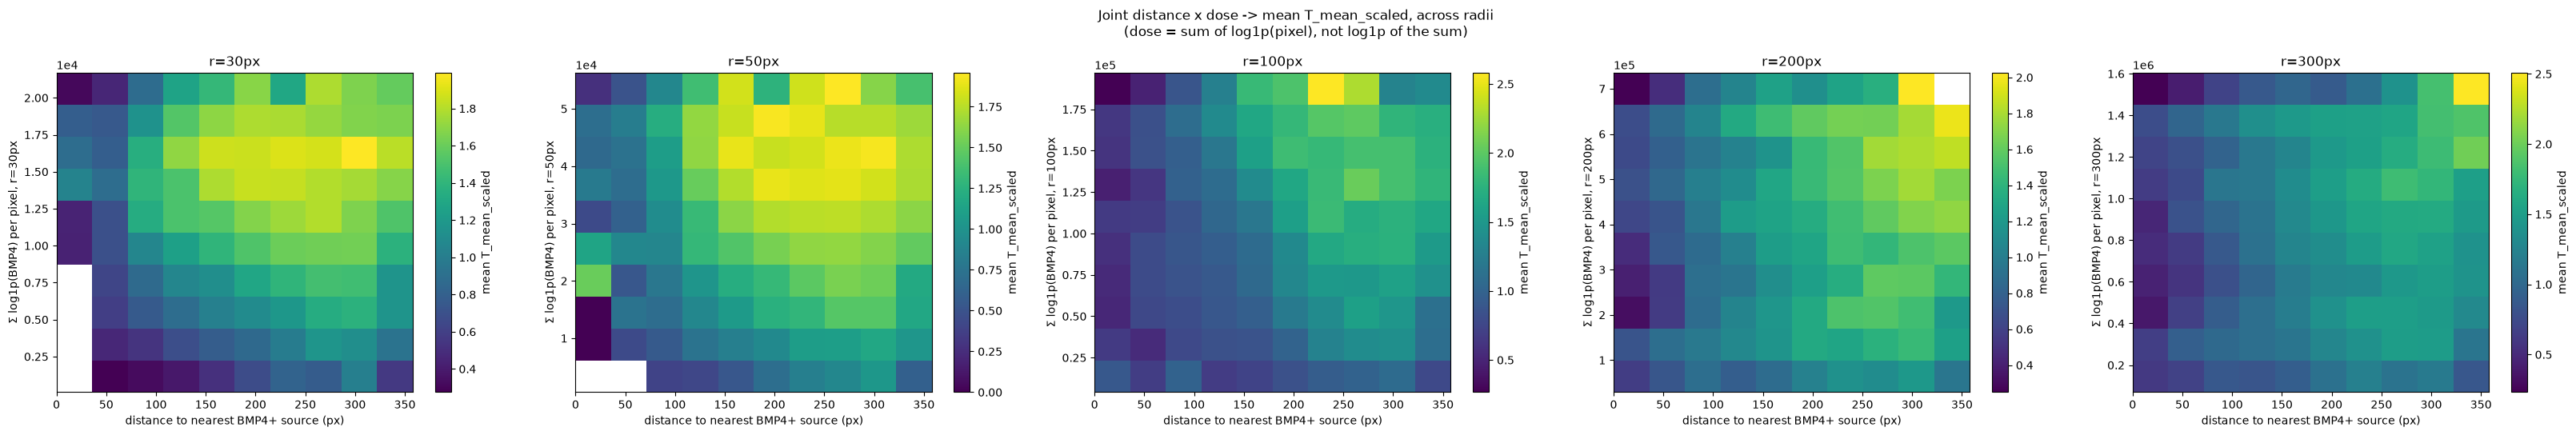

In [20]:
from scipy.stats import binned_statistic_2d

N_2D_BINS = 10
fig, axes = plt.subplots(1, len(RADII), figsize=(6.5 * len(RADII), 5.5))
axes = np.atleast_1d(axes)

for ax, r in zip(axes, RADII):
    col = log_dose_cols[r]
    dist_edges = np.unique(np.quantile(cell_df['dist_to_BMP4_source'], np.linspace(0, 1, N_2D_BINS + 1)))
    dose_edges = np.unique(np.quantile(cell_df[col], np.linspace(0, 1, N_2D_BINS + 1)))
    mean_T, xedges, yedges, _ = binned_statistic_2d(
        cell_df['dist_to_BMP4_source'], cell_df[col], cell_df['T_mean_scaled'],
        statistic='mean', bins=[dist_edges, dose_edges],
    )
    im = ax.imshow(mean_T.T, origin='lower', aspect='auto', cmap='viridis',
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    ax.set_xlabel('distance to nearest BMP4+ source (px)')
    ax.set_ylabel(f'Σ log1p(BMP4) per pixel, r={r}px')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.set_title(f'r={r}px')
    fig.colorbar(im, ax=ax, label='mean T_mean_scaled')

fig.suptitle('Joint distance x dose -> mean T_mean_scaled, across radii\n(dose = sum of log1p(pixel), not log1p of the sum)')
fig.tight_layout()
plt.savefig(f'{fig_dir}/BMP4_dose_distanceheatmap.png', dpi=300)
plt.show()

## Summary

**Dataset.** `W8_pattern1_Sox17_Brachyury` -- 111,511 segmented cells, of which 3,859
(3.5%) are classified `BMP4+` ("sender") cells. These form two dense, geometrically
clean clusters (a filled disk and a ring, found during earlier exploration of this
image) that are almost certainly the deliberate optogenetic light pattern, plus a
scattering of singleton `BMP4+` cells elsewhere in the colony of uncertain origin
(background/leaky expression vs. genuine relay signaling) -- this analysis does not
distinguish between the two populations, so every metric below is influenced by both.

**Distance to nearest sender.** Mean 97.7px, median 93.1px (std 55.2px, range
0-457.6px). `T_mean` rises modestly with distance from the nearest single `BMP4+`
cell (Spearman r = **+0.231**, p < 0.001, n = 111,511) -- cells farther from a
sender tend to have somewhat *higher* T, the opposite of the naive "closer to the
morphogen source = more induction" expectation. The Pearson r (+0.009) is
negligible, meaning this is a real rank-order relationship, not a strong linear one.

**Three ways of asking "how much BMP4 is nearby," swept across radii (30/50/100/
200/300px):**

| radius (px) | pixel-based dose (log, `pixel_dose_log_spearman`) | neighborhood BMP4_mean total | neighborhood sender count |
|---|---|---|---|
| 30  | -0.010 | **+0.286** | -0.154 |
| 50  | -0.063 | +0.265 | -0.212 |
| 100 | -0.104 | +0.248 | **-0.238** |
| 200 | -0.049 | +0.141 | -0.170 |
| 300 | -0.018 | +0.044 | -0.086 |

*(Spearman r vs. `T_mean`, all p < 0.001 given the sample size -- treat the p-values
as a consequence of n≈111K, not evidence of a large effect; every |r| here is
modest.)*

- **Pixel-based cumulative dose** (`log_dose_cols`: background-subtract + log1p
  EACH pixel, then SUM over every pixel in the radius -- a sum of log1p'd values,
  not a log1p of the sum, so the total is still large in absolute terms) is
  essentially null-to-weakly-negative at every radius tested, bottoming out around
  r=100px. Averaging over a huge, mostly-background area seems to dilute out
  whatever local structure matters.
- **Neighborhood BMP4_mean total** (sum of nearby CELLS' own average BMP4
  intensity -- fully continuous, no `BMP4+` threshold anywhere) is consistently
  **positive**, strongest at the smallest radius tested (30px) and decaying
  monotonically as radius grows to 300px. This says: cells surrounded by other
  cells with elevated BMP4 signal -- thresholded "sender" or not -- tend to have
  higher T, and this effect is a short-range (tens of px), not long-range,
  phenomenon.
- **Neighborhood sender count** (how many `BMP4+`-thresholded cells are nearby) is
  consistently **negative** at every radius, peaking (most negative) at an
  intermediate radius (100px). This is the opposite sign from the BMP4_mean-total
  metric above, despite both describing "BMP4 in the neighborhood."

**The central finding.** The two continuous, threshold-free metrics (distance to
nearest sender: +0.231; neighborhood BMP4_mean total: up to +0.286) point in the
*same* direction -- more distance / less concentrated nearby BMP4 signal associates
with modestly higher T. The one metric that still depends on the `BMP4+` binary
call (neighborhood sender count) points the *opposite* direction at every radius.
That divergence is a real, reproducible pattern across all five radii tested here,
not a fluke of one bin choice -- and it lines up with the original concern that
motivated dropping `BMP4+`/`T+` everywhere possible: the threshold may be carving
the cell population up in a way that doesn't track the same thing the continuous
intensity does, and by extension may not track the underlying biology cleanly
either.

**Unscaled vs. scaled, side by side.** Repeating the same relationship in raw vs.
transformed units confirms the direction holds either way, though raw units are
visually much noisier:

- *Unscaled* (`T_mean` vs. raw pixel-based `BMP4_dose_r{radius}`): Spearman ranges
  from -0.034 (r=30px) down to **-0.213** (r=100px, the strongest) and back up to
  -0.069 (r=300px) -- same negative direction and same r=100px trough as the
  log-transformed pixel dose above, so the transform isn't manufacturing the sign.
  Pearson stays near 0 throughout (-0.007 to -0.022); raw `T_mean`'s handful of
  extreme outliers (up to 50,000, vs. a typical value in the low hundreds) make the
  linear correlation close to meaningless here -- Spearman is the number to trust.
- *Scaled* (`T_mean_scaled` vs. log1p `BMP4` neighborhood total): Spearman is
  **+0.239** at r=30px, decaying monotonically to +0.061 at r=300px -- consistent
  with the neighborhood-total row of the table above, confirming that effect is
  concentrated at short range regardless of which exact pair of transformed columns
  is used.

**Caveats.** Single image, single condition, single timepoint -- correlational, not
causal, and not yet checked for replication across other wells/fields. Effect sizes
throughout are modest (|r| < 0.29); the very small p-values reflect the large cell
count, not a strong effect. The two dense sender clusters and the scattered
singleton `BMP4+` cells are pooled together in every metric above -- separating them
(e.g. via spatial clustering on `BMP4+` centroids) would help determine whether the
sign flip between the neighborhood-total and sender-count metrics is driven by one
population or holds for both. A smooth distance-decay dose kernel (Gaussian/
inverse-square) instead of a hard per-radius cutoff would also remove the
arbitrariness of picking specific radii, given that the "best" radius already
differs between the BMP4_mean-total metric (30px) and the sender-count metric
(100px).